In [ ]:
import pandas as pd

First, mount your Google Drive to access files stored there.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

# List contents of your Google Drive's root folder
print(os.listdir('/content/drive/MyDrive/datasets'))

Once your drive is mounted, you can load your dataset using pandas. For example, if it's a CSV file, you can use `pd.read_csv()`:

In [ ]:
import pandas as pd

# Replace 'path/to/your/file.csv' with the actual path to your file in Google Drive
df = pd.read_excel('/content/drive/MyDrive/datasets/PS.xlsx')

# Display the first 5 rows of the DataFrame
df.describe()

# Exploratory Structural Analysis (ESA)
## (a) Perform a structural audit of the dataset:
### 1. Feature Types

In [ ]:
df.dtypes

### 2. Ranges

In [ ]:
for col in df.select_dtypes(include=['int64','float64']):
    print(col, df[col].min(), df[col].max())

### 3. Distribution Analysis

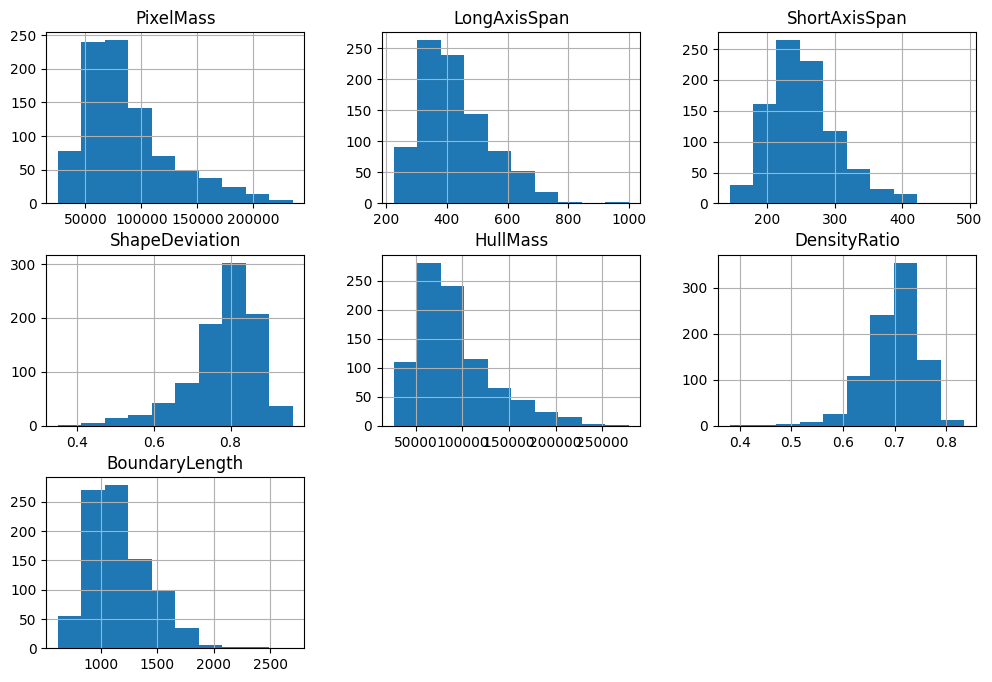

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()

Find Skew -

~0 → symmetric

+1 → highly right skewed

< -1 → highly left skewed

In [ ]:
df_input = df.iloc[:,:-1]
df_input.skew()

,0
PixelMass,1.175237
LongAxisSpan,0.989544
ShortAxisSpan,0.800049
ShapeDeviation,-1.327503
HullMass,1.242904
DensityRatio,-1.151505
BoundaryLength,1.017761


PixelMass and HullMass are highly right skewed -> would need log transform and then scaling

ShapeDeviation & DensityRatio are highly left skewed -> would need log transform and then scaling



### 4. Detect hidden patterns (e.g., scale imbalance)

First find the ranges

In [ ]:
for col in df_input:
    print(col, df[col].min(), df[col].max())

PixelMass 25387 235047
LongAxisSpan 225.629541 997.2919406
ShortAxisSpan 143.7108718 492.2752785
ShapeDeviation 0.348729642 0.96212444
HullMass 26139 278217
DensityRatio 0.379856115 0.835454545
BoundaryLength 619.074 2697.753


Find Standard Deviation as Scale Indicator

In [ ]:
df_input.std().sort_values(ascending=False)

,0
HullMass,40769.290132
PixelMass,39002.111390
BoundaryLength,273.764315
LongAxisSpan,116.035121
ShortAxisSpan,49.988902
ShapeDeviation,0.090318
DensityRatio,0.053468


Interpretation:

##### High std → large spread → dominates model

##### Compare ratios:

##### std = 50 vs std = 50000 → imbalance

HullMass, PixelMass have too high standard deviation, these 2 featurs will dominate the model and would need standardisation

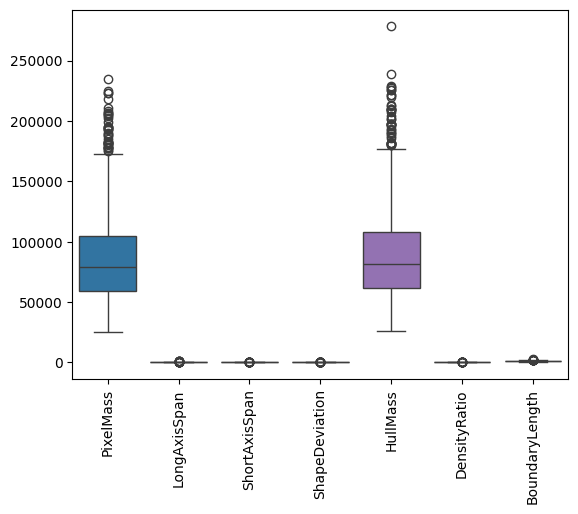

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.xticks(rotation=90)
plt.show()

In [ ]:
scale_ratio = df_input.max() / df_input.min().replace(0, 1)
print(scale_ratio.sort_values(ascending=False))

HullMass          10.643751
PixelMass          9.258558
LongAxisSpan       4.420042
BoundaryLength     4.357723
ShortAxisSpan      3.425456
ShapeDeviation     2.758941
DensityRatio       2.199397
dtype: float64


## (b) Construct multi-prespective visualizations

Univariate histplots

In [ ]:
def plot_histograms(df):

  fig, axes = plt.subplots(3, 3, figsize=(9, 9)) # Create a 2x2 grid of subplots

  sns.histplot(data=df, x='PixelMass', hue='VariantLabel', kde=True, ax=axes[0, 0])
  axes[0, 0].set_title('Hisplot of PixelMass')

  sns.histplot(data=df, x='LongAxisSpan', hue='VariantLabel', kde=True, ax=axes[0, 1])
  axes[0, 1].set_title('Hisplot of LongAxisSpan')

  sns.histplot(data=df, x='ShortAxisSpan', hue='VariantLabel', kde=True, ax=axes[0, 2])
  axes[0, 2].set_title('Hisplot of ShortAxisSpan')

  sns.histplot(data=df, x='ShapeDeviation', hue='VariantLabel', kde=True, ax=axes[1, 0])
  axes[1, 0].set_title('Hisplot of ShapeDeviation')

  sns.histplot(data=df, x='HullMass', hue='VariantLabel', kde=True, ax=axes[1, 1])
  axes[1, 1].set_title('Hisplot of HullMass')

  sns.histplot(data=df, x='DensityRatio', hue='VariantLabel', kde=True, ax=axes[1, 2])
  axes[1, 2].set_title('Hisplot of DensityRatio')

  sns.histplot(data=df, x='BoundaryLength', hue='VariantLabel', kde=True, ax=axes[2, 0])
  axes[2, 0].set_title('Hisplot of BoundaryLength')

  plt.tight_layout()
  plt.show()

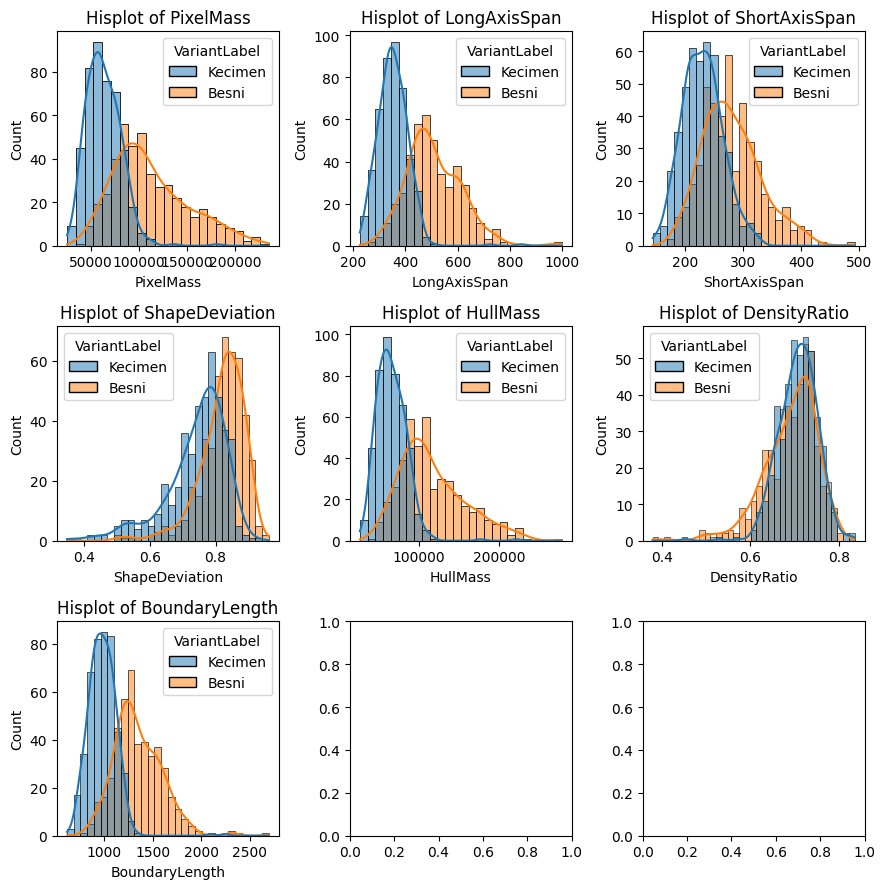

In [ ]:
plot_histograms( df )

Univariate Boxplots

In [ ]:
def plot_boxplots(df):

  fig, axes = plt.subplots(3, 3, figsize=(9, 9)) # Create a 2x2 grid of subplots

  sns.boxplot(data=df, x='PixelMass', ax=axes[0, 0])
  axes[0, 0].set_title('Boxplot of PixelMass')

  sns.boxplot(data=df, x='LongAxisSpan', ax=axes[0, 1])
  axes[0, 1].set_title('Hisplot of LongAxisSpan')

  sns.boxplot(data=df, x='ShortAxisSpan', ax=axes[0, 2])
  axes[0, 2].set_title('Hisplot of ShortAxisSpan')

  sns.boxplot(data=df, x='ShapeDeviation', ax=axes[1, 0])
  axes[1, 0].set_title('Hisplot of ShapeDeviation')

  sns.boxplot(data=df, x='HullMass', ax=axes[1, 1])
  axes[1, 1].set_title('Hisplot of HullMass')

  sns.boxplot(data=df, x='DensityRatio', ax=axes[1, 2])
  axes[1, 2].set_title('Hisplot of DensityRatio')

  sns.boxplot(data=df, x='BoundaryLength', ax=axes[2, 0])
  axes[2, 0].set_title('Hisplot of BoundaryLength')

  plt.tight_layout()
  plt.show()

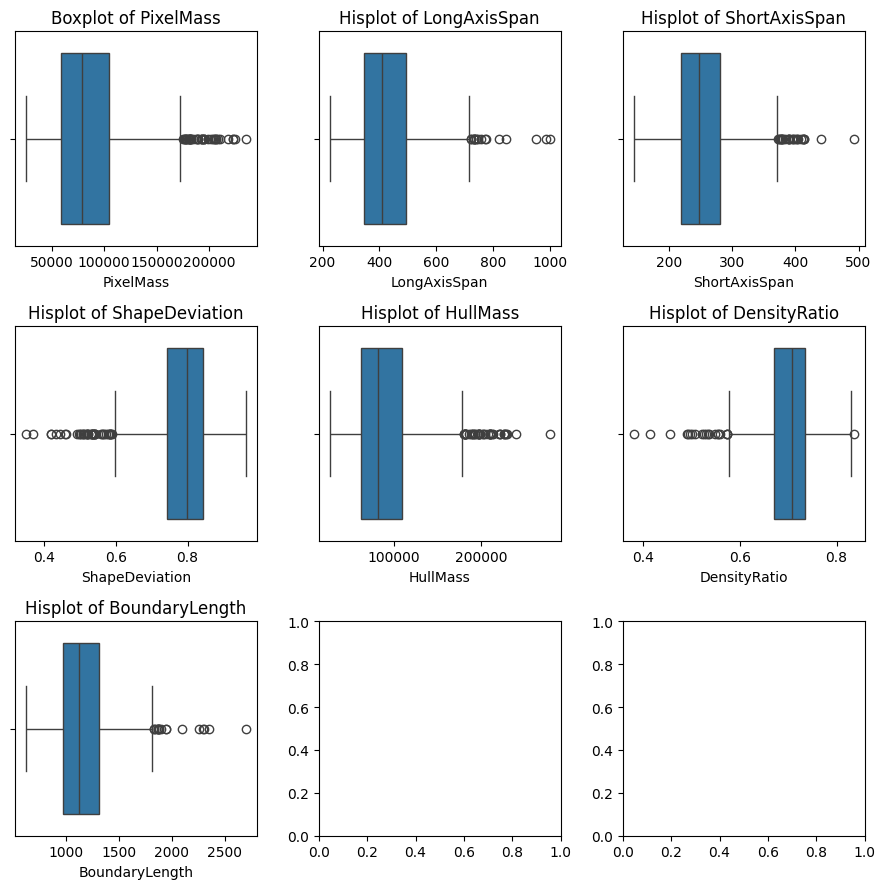

In [ ]:
plot_boxplots( df )

### Pairwise relationships (bivariate)

Scatterplots

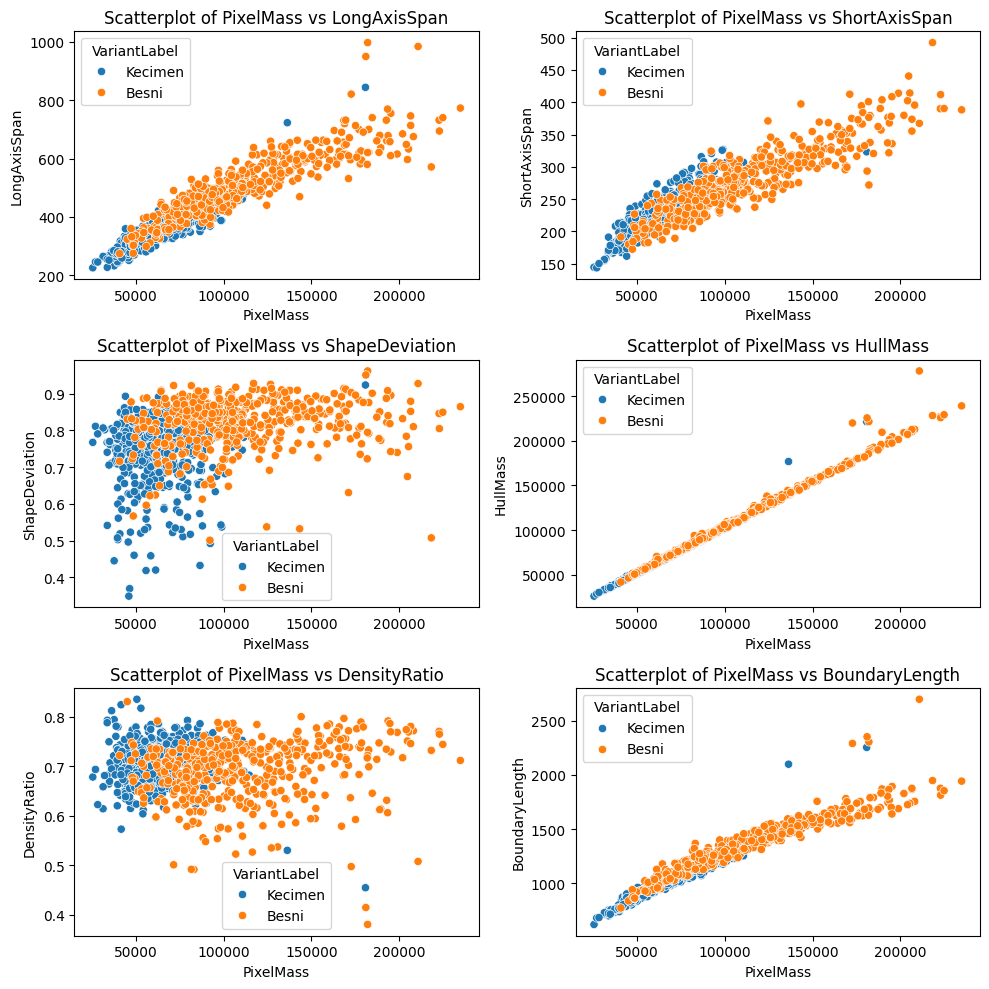

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10)) # Create a 2x2 grid of subplots

sns.scatterplot(data=df, x='PixelMass', y='LongAxisSpan', hue='VariantLabel', ax=axes[0, 0])
axes[0, 0].set_title('Scatterplot of PixelMass vs LongAxisSpan')

sns.scatterplot(data=df, x='PixelMass', y='ShortAxisSpan', hue='VariantLabel', ax=axes[0, 1])
axes[0, 1].set_title('Scatterplot of PixelMass vs ShortAxisSpan')

sns.scatterplot(data=df, x='PixelMass', y='ShapeDeviation', hue='VariantLabel', ax=axes[1, 0])
axes[1, 0].set_title('Scatterplot of PixelMass vs ShapeDeviation')

sns.scatterplot(data=df, x='PixelMass', y='HullMass', hue='VariantLabel', ax=axes[1, 1])
axes[1, 1].set_title('Scatterplot of PixelMass vs HullMass')

sns.scatterplot(data=df, x='PixelMass', y='DensityRatio', hue='VariantLabel', ax=axes[2, 0])
axes[2, 0].set_title('Scatterplot of PixelMass vs DensityRatio')

sns.scatterplot(data=df, x='PixelMass', y='BoundaryLength', hue='VariantLabel', ax=axes[2, 1])
axes[2, 1].set_title('Scatterplot of PixelMass vs BoundaryLength')

plt.tight_layout()
plt.show()

Class-conditional feature distributions

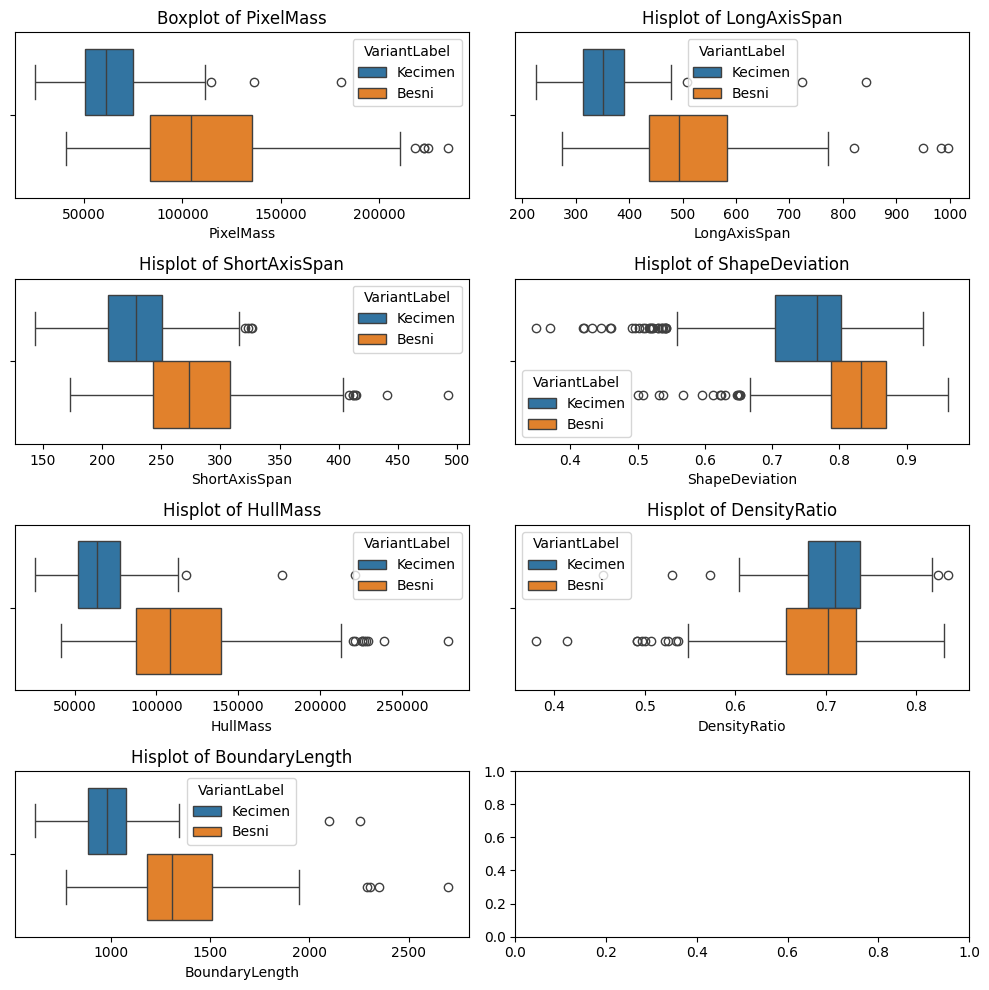

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(10, 10)) # Create a 2x2 grid of subplots

sns.boxplot(data=df, x='PixelMass', hue='VariantLabel', ax=axes[0, 0])
axes[0, 0].set_title('Boxplot of PixelMass')

sns.boxplot(data=df, x='LongAxisSpan', hue='VariantLabel', ax=axes[0, 1])
axes[0, 1].set_title('Hisplot of LongAxisSpan')

sns.boxplot(data=df, x='ShortAxisSpan', hue='VariantLabel', ax=axes[1, 0])
axes[1, 0].set_title('Hisplot of ShortAxisSpan')

sns.boxplot(data=df, x='ShapeDeviation', hue='VariantLabel', ax=axes[1, 1])
axes[1, 1].set_title('Hisplot of ShapeDeviation')

sns.boxplot(data=df, x='HullMass', hue='VariantLabel', ax=axes[2, 0])
axes[2, 0].set_title('Hisplot of HullMass')

sns.boxplot(data=df, x='DensityRatio', hue='VariantLabel', ax=axes[2, 1])
axes[2, 1].set_title('Hisplot of DensityRatio')

sns.boxplot(data=df, x='BoundaryLength', hue='VariantLabel', ax=axes[3, 0])
axes[3, 0].set_title('Hisplot of BoundaryLength')

plt.tight_layout()
plt.show()

### (c) Compute and interpret feature interaction structure

Correlation Matrix

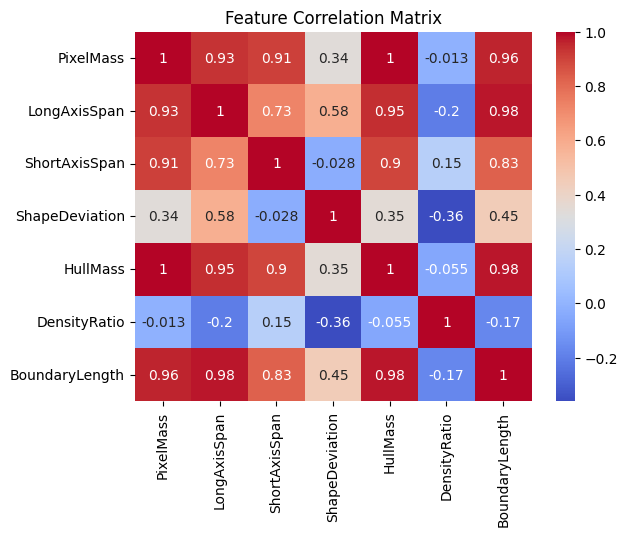

In [ ]:
corr = df.drop('VariantLabel', axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

X = df.drop('VariantLabel', axis=1)
y = df['VariantLabel']

mi = mutual_info_classif(X, y)

mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(mi_scores)

BoundaryLength    0.358507
LongAxisSpan      0.348341
HullMass          0.297661
PixelMass         0.277582
ShortAxisSpan     0.134869
ShapeDeviation    0.129117
DensityRatio      0.029344
dtype: float64


<Axes: title={'center': 'Mutual Information Scores'}>

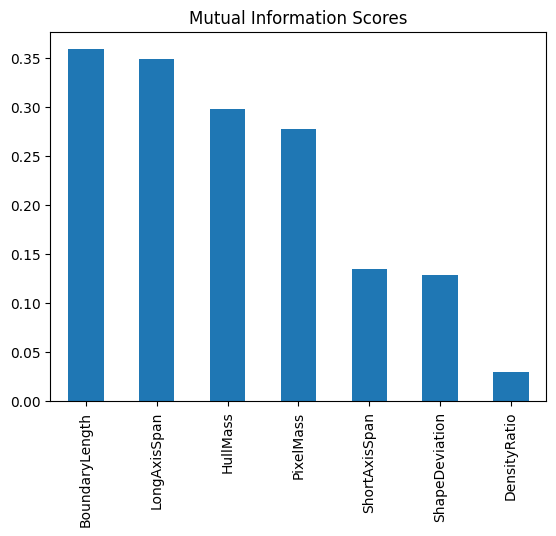

In [ ]:
mi_scores.plot(kind='bar', title='Mutual Information Scores')

### Mutual Information analysis revealed that BoundaryLength and LongAxisSpan are the most informative features, indicating that geometric characteristics dominate class differentiation. Mass-related features such as HullMass and PixelMass also contribute significantly. In contrast, DensityRatio exhibited negligible MI, suggesting minimal predictive value. The presence of multiple high-ranking geometric features indicates potential redundancy, highlighting the need for dimensionality reduction or feature selection.

Drop:

DensityRatio

Transform + scale:
PixelMass (log + standardize)
HullMass (log + standardize)

# Data Conditioning & Representation Learning

## 1. Data sanitization pipeline

### IQR

In [ ]:
import pandas as pd

df_clean_iqr = df.copy()
outlier_summary = {}

for col in df.select_dtypes(include=['int64','float64']):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'PixelMass': 41, 'LongAxisSpan': 17, 'ShortAxisSpan': 26, 'ShapeDeviation': 43, 'HullMass': 42, 'DensityRatio': 21, 'BoundaryLength': 17}


In [ ]:
for col in df.select_dtypes(include=['int64','float64']):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean_iqr = df_clean_iqr[
        (df_clean_iqr[col] >= lower) & (df_clean_iqr[col] <= upper)
    ]

In [ ]:
print(f"Original size: {df.shape}")
print(f"After IQR: {df_clean_iqr.shape}")

Original size: (900, 8)
After IQR: (795, 8)


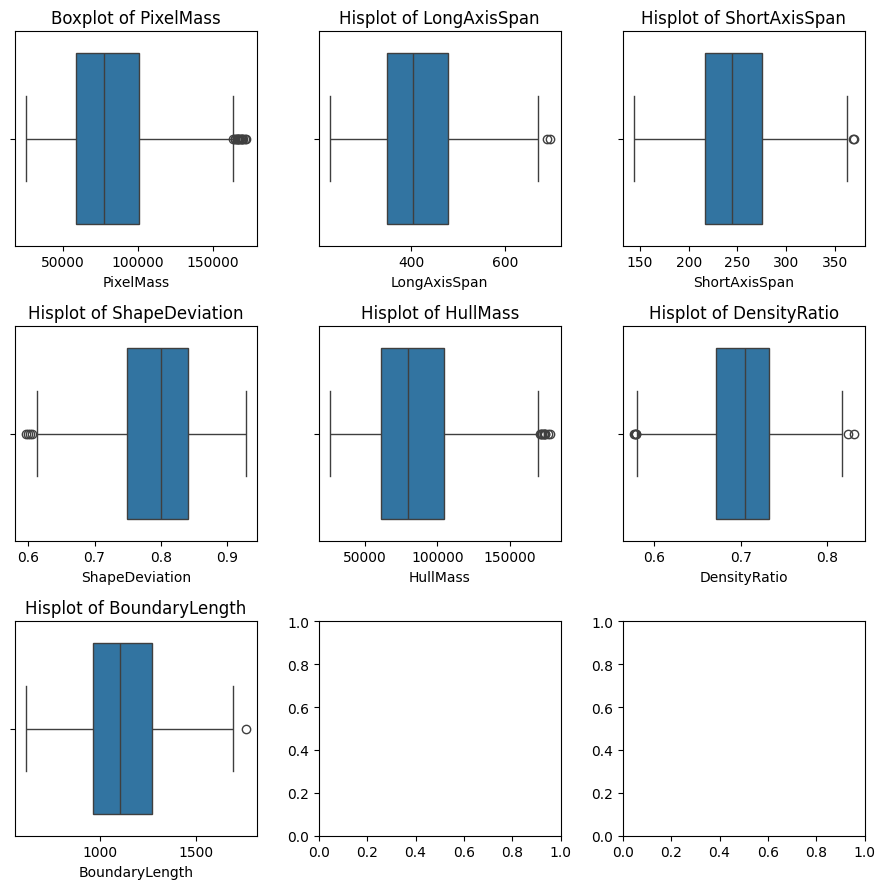

In [ ]:
plot_boxplots( df_clean_iqr )

Interpretation
HullMass → many outliers
PixelMass → some outliers

👉 IQR will:

flag these aggressively
possibly remove many rows

Limitation:

Works per feature independently

Cannot detect multivariate anomalies

### Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

df_iso = df.copy()

# Step 1: Log transform skewed features
df_iso['HullMass'] = np.log1p(df_iso['HullMass'])

# Step 1: Log transform skewed features
df_iso['PixelMass'] = np.log1p(df_iso['PixelMass'])

X = df_iso.drop('VariantLabel', axis=1)
iso = IsolationForest(contamination=0.05, random_state=42)
outliers = iso.fit_predict(X)

# -1 = outlier, 1 = normal
df_clean_iso = df_iso[outliers == 1]

print("Original size:", df_iso.shape)
print("After IsolationForest:", df_clean_iso.shape)
print(df_clean_iso.describe())

Original size: (900, 8)
After IsolationForest: (855, 8)
        PixelMass  LongAxisSpan  ShortAxisSpan  ShapeDeviation    HullMass  \
count  855.000000    855.000000     855.000000      855.000000  855.000000   
mean    11.285861    425.922941     252.785850        0.782867   11.322105   
std      0.382132    102.601484      45.210833        0.084043    0.379382   
min     10.450452    249.740227     161.702366        0.418382   10.505533   
25%     10.998368    346.806566     219.704859        0.742153   11.034613   
50%     11.268980    405.936594     247.707867        0.798307   11.306221   
75%     11.542576    486.834264     277.411345        0.841030   11.582843   
max     12.226987    731.561876     408.535619        0.928094   12.251252   

       DensityRatio  BoundaryLength  
count    855.000000      855.000000  
mean       0.700677     1152.811260  
std        0.047689      237.710343  
min        0.491002      737.637000  
25%        0.671966      969.741500  
50%        0.

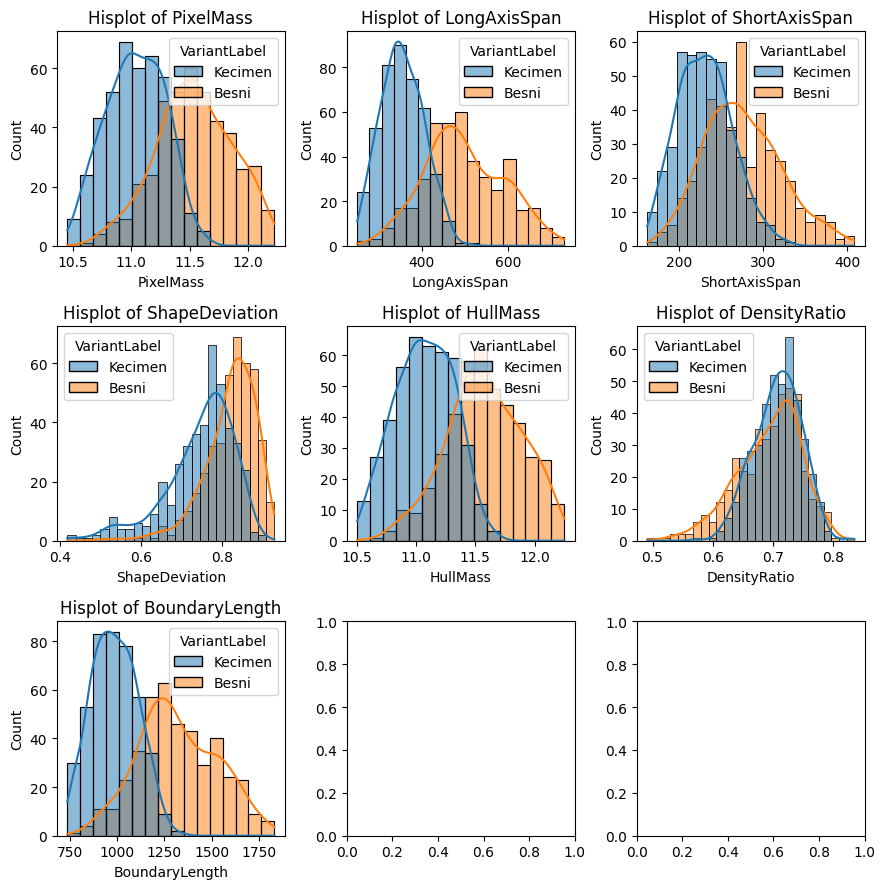

In [ ]:
plot_histograms( df_clean_iso )

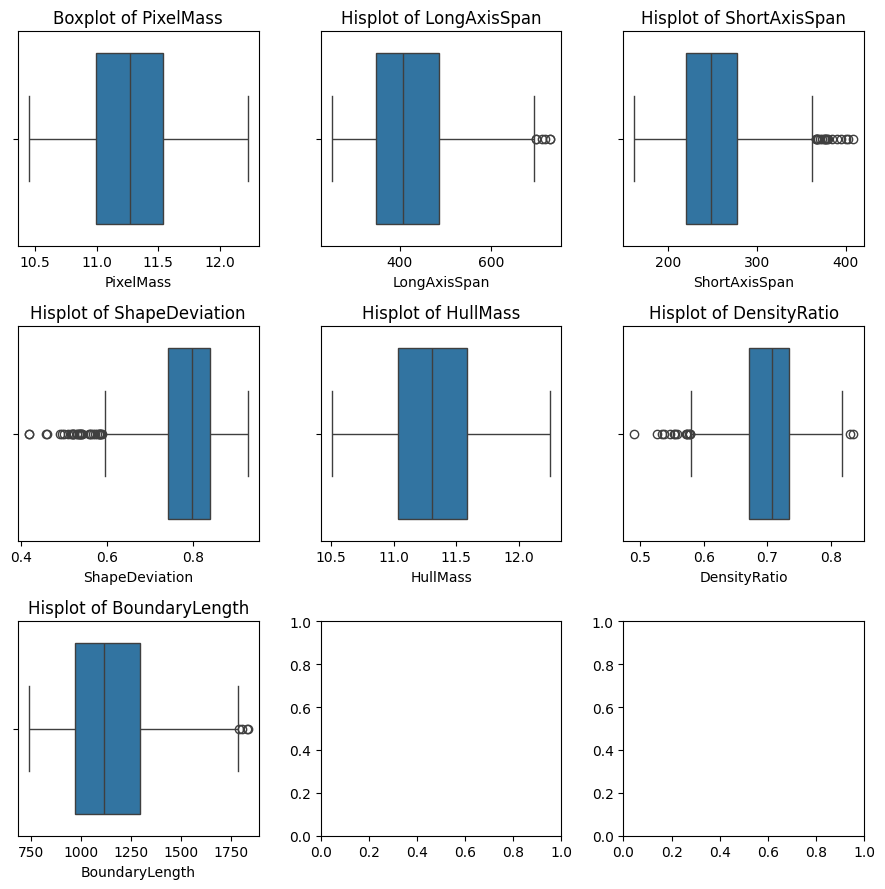

In [ ]:
plot_boxplots( df_clean_iso )

In [ ]:
df.select_dtypes(include=['number']).skew()

,0
PixelMass,1.175237
LongAxisSpan,0.989544
ShortAxisSpan,0.800049
ShapeDeviation,-1.327503
HullMass,1.242904
DensityRatio,-1.151505
BoundaryLength,1.017761


In [ ]:
df_clean_iso.select_dtypes(include=['number']).skew()

,0
PixelMass,0.246118
LongAxisSpan,0.682597
ShortAxisSpan,0.625723
ShapeDeviation,-1.197486
HullMass,0.240233
DensityRatio,-0.639653
BoundaryLength,0.602949


In [ ]:
df_clean_iso.describe()

,PixelMass,LongAxisSpan,ShortAxisSpan,ShapeDeviation,HullMass,DensityRatio,BoundaryLength
count,855.000000,855.000000,855.000000,855.000000,855.000000,855.000000,855.000000
mean,11.285861,425.922941,252.785850,0.782867,11.322105,0.700677,1152.811260
std,0.382132,102.601484,45.210833,0.084043,0.379382,0.047689,237.710343
min,10.450452,249.740227,161.702366,0.418382,10.505533,0.491002,737.637000
25%,10.998368,346.806566,219.704859,0.742153,11.034613,0.671966,969.741500
50%,11.268980,405.936594,247.707867,0.798307,11.306221,0.707308,1114.736000
75%,11.542576,486.834264,277.411345,0.841030,11.582843,0.733666,1295.323500
max,12.226987,731.561876,408.535619,0.928094,12.251252,0.835455,1831.909000


## Apply representation transformation techniques:
• Standardization vs Normalization vs Robust Scaling

• Justify mathematically which is suitable and why

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_clean_iso.drop('VariantLabel', axis=1)

Standardization

In [ ]:
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

Normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

Robust Scaler

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)

In [ ]:
X_std_df = pd.DataFrame(X_std, columns=X.columns)
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)
X_robust_df = pd.DataFrame(X_robust, columns=X.columns)

In [ ]:
def plot_kde_distributions(X_std_df, X_minmax_df, X_robust_df, coloumn):

  plt.figure(figsize=(12,4))

  plt.subplot(1,3,1)
  sns.kdeplot(X_std_df[coloumn], fill=True)
  plt.title('Standardized')

  plt.subplot(1,3,2)
  sns.kdeplot(X_minmax_df[coloumn], fill=True)
  plt.title('Min-Max')

  plt.subplot(1,3,3)
  sns.kdeplot(X_robust_df[coloumn], fill=True)
  plt.title('Robust')

  plt.show()

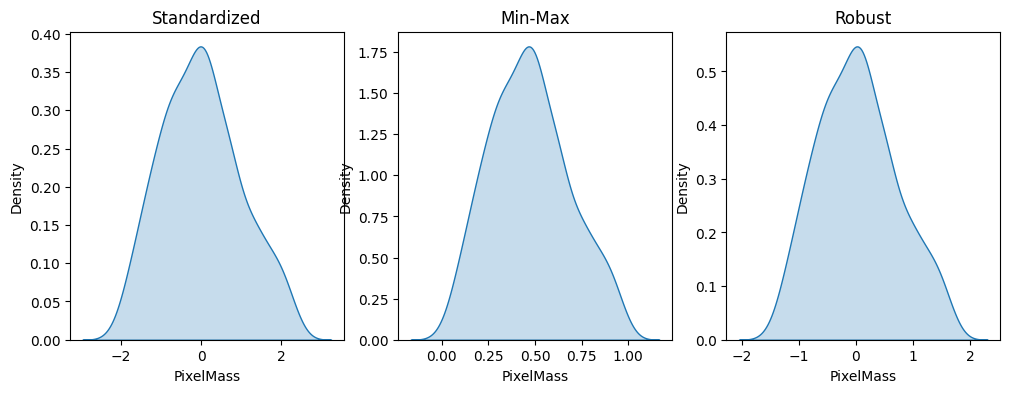

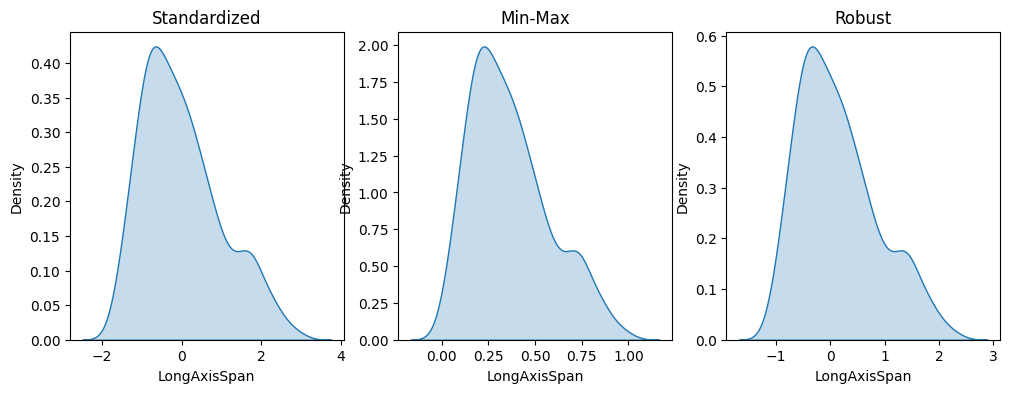

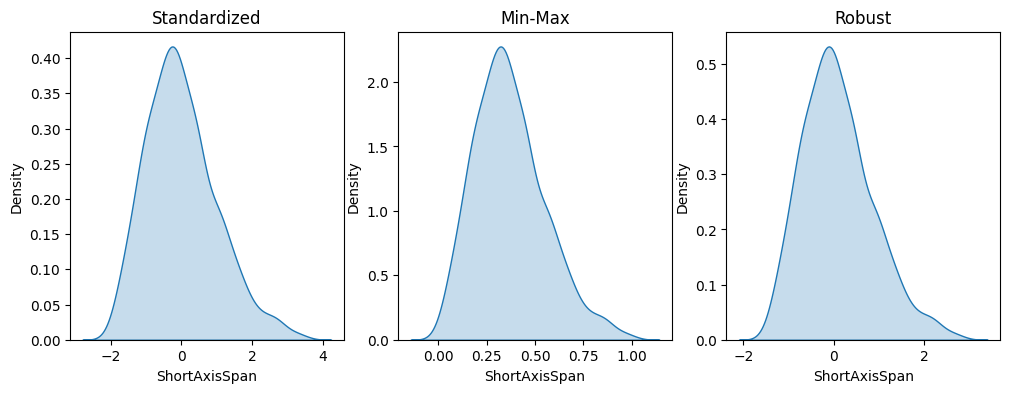

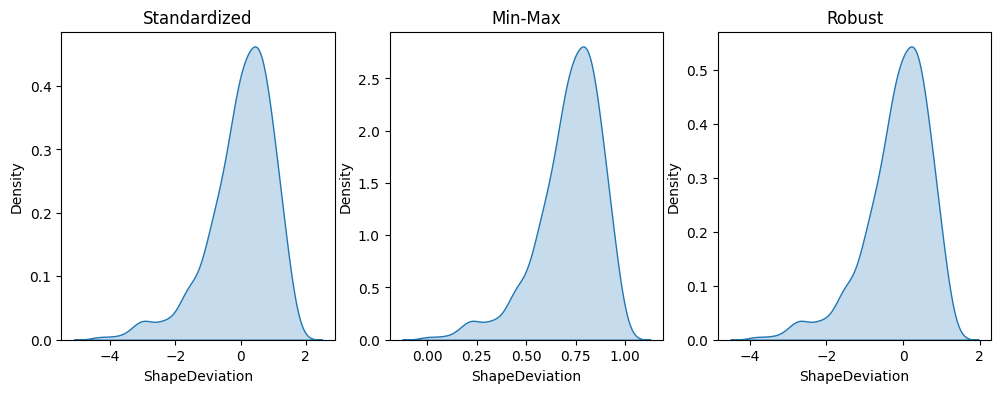

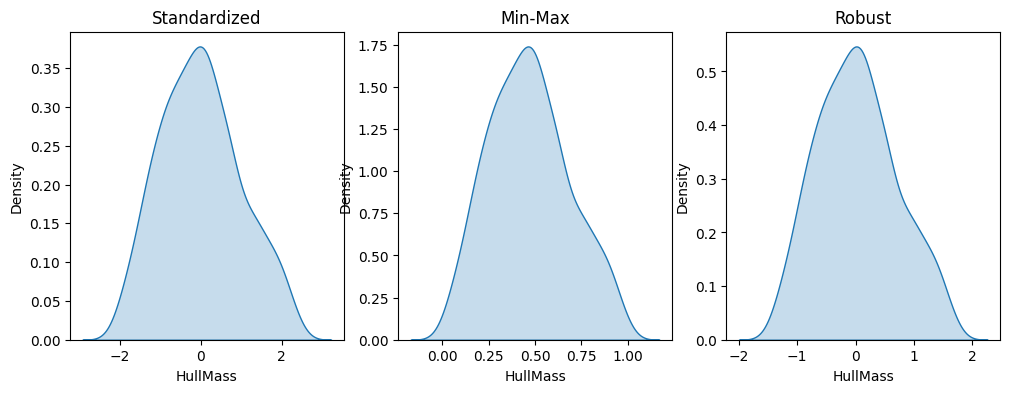

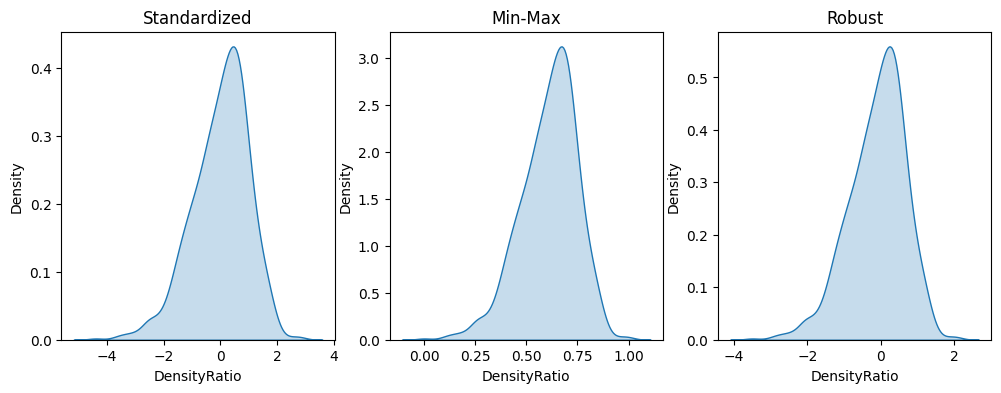

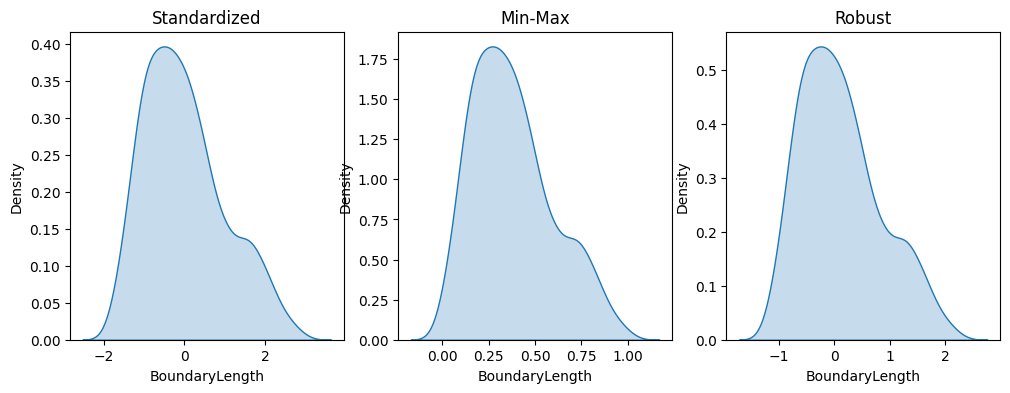

In [ ]:
for col in X_std_df.columns:
  plot_kde_distributions(X_std_df, X_minmax_df, X_robust_df, col )

In [ ]:
X_std_df.describe()

,PixelMass,LongAxisSpan,ShortAxisSpan,ShapeDeviation,HullMass,DensityRatio,BoundaryLength
count,8.550000e+02,855.000000,8.550000e+02,8.550000e+02,8.550000e+02,8.550000e+02,855.000000
mean,2.393407e-15,0.000000,-3.324177e-17,1.329671e-15,-1.396154e-15,-1.080357e-15,0.000000
std,1.000585e+00,1.000585,1.000585e+00,1.000585e+00,1.000585e+00,1.000585e+00,1.000585
min,-2.187457e+00,-1.718161,-2.015818e+00,-4.339427e+00,-2.153636e+00,-4.399240e+00,-1.747578
25%,-7.527800e-01,-0.771555,-7.321332e-01,-4.847313e-01,-7.582361e-01,-6.023817e-01,-0.770589
50%,-4.420184e-02,-0.194910,-1.123836e-01,1.838131e-01,-4.189312e-02,1.391262e-01,-0.160269
75%,6.721921e-01,0.594016,5.450001e-01,6.924655e-01,6.876725e-01,6.921585e-01,0.599871
max,2.464274e+00,2.980637,3.446982e+00,1.729010e+00,2.450540e+00,2.827809e+00,2.858501


In [ ]:
X_minmax_df.describe()

,PixelMass,LongAxisSpan,ShortAxisSpan,ShapeDeviation,HullMass,DensityRatio,BoundaryLength
count,855.000000,855.000000,855.000000,855.000000,855.000000,855.000000,855.000000
mean,0.470246,0.365660,0.369008,0.715081,0.467757,0.608719,0.379407
std,0.215100,0.212945,0.183163,0.164884,0.217321,0.138450,0.217231
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.308418,0.201457,0.234987,0.635204,0.303073,0.525368,0.212109
50%,0.460744,0.324179,0.348436,0.745372,0.458658,0.627969,0.344612
75%,0.614750,0.492078,0.468774,0.829191,0.617115,0.704492,0.509642
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
X_robust_df.describe()

,PixelMass,LongAxisSpan,ShortAxisSpan,ShapeDeviation,HullMass,DensityRatio,BoundaryLength
count,855.000000,855.000000,855.000000,855.000000,855.000000,855.000000,855.000000
mean,0.031019,0.142731,0.087997,-0.156145,0.028974,-0.107472,0.116945
std,0.702179,0.732723,0.783462,0.849973,0.692011,0.772927,0.730109
min,-1.504068,-1.115468,-1.490396,-3.842382,-1.460495,-3.505775,-1.158230
25%,-0.497258,-0.422274,-0.485266,-0.567912,-0.495428,-0.572796,-0.445339
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.502742,0.577726,0.514734,0.432088,0.504572,0.427204,0.554661
max,1.760368,2.325435,2.786996,1.312607,1.723783,2.076940,2.202742


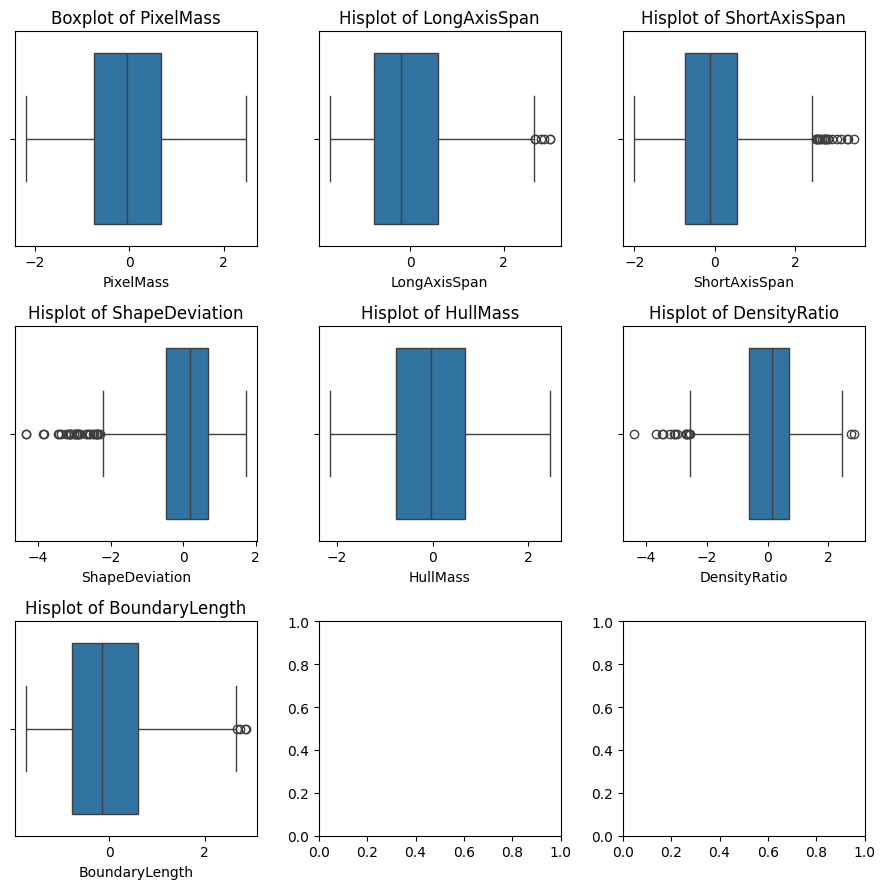

In [ ]:
plot_boxplots( X_std_df )

Mathematical justification

Robust Scaling

Formula:

𝑥′= 𝑥−Median / 𝐼𝑄𝑅

This uses the median and interquartile range instead of mean and standard deviation, so it is less affected by outliers.

Conclusion

Although standardization is a strong default for many linear models, robust scaling is more appropriate here because the data still contains outlier structure even after skewness correction. Therefore, the final conditioned representation uses:

1. Log Transformation for skewness correction
2. Isolation forest for outlier removal
3. RobustScaler for scale normalization

## 2(c) Feature importance using two paradigms

We need:

1. Model-based
2. Statistical

We use:
1. Random Forest feature importance
2. Mutual Information and ANOVA F-score

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier

# Construct final transformed dataset for importance analysis
X_feat = X.copy()

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(df_clean_iso['VariantLabel'])

# Statistical importance: Mutual Information
mi_scores = mutual_info_classif(X_feat, y_enc, random_state=42)
mi_df = pd.DataFrame({
    "Feature": X_feat.columns,
    "MutualInformation": mi_scores
}).sort_values("MutualInformation", ascending=False)

print("Mutual Information:\n")
print(mi_df)

# Statistical importance: ANOVA F-test
f_vals, p_vals = f_classif(X_feat, y_enc)
anova_df = pd.DataFrame({
    "Feature": X_feat.columns,
    "F_score": f_vals,
    "p_value": p_vals
}).sort_values("F_score", ascending=False)

print("\nANOVA:\n")
print(anova_df)

# Model-based importance: Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_feat, y_enc)

rf_df = pd.DataFrame({
    "Feature": X_feat.columns,
    "RF_Importance": rf.feature_importances_
}).sort_values("RF_Importance", ascending=False)

print("\nRandom Forest importance:\n")
print(rf_df)

Mutual Information:

          Feature  MutualInformation
6  BoundaryLength           0.354766
1    LongAxisSpan           0.344271
4        HullMass           0.293485
0       PixelMass           0.271212
3  ShapeDeviation           0.147467
2   ShortAxisSpan           0.124215
5    DensityRatio           0.029897

ANOVA:

          Feature     F_score        p_value
6  BoundaryLength  813.356261  3.608455e-126
1    LongAxisSpan  805.446374  2.752549e-125
4        HullMass  683.652276  3.862281e-111
0       PixelMass  644.633083  2.280673e-106
2   ShortAxisSpan  274.459514   1.175680e-53
3  ShapeDeviation  215.994465   9.404830e-44
5    DensityRatio   21.496784   4.099052e-06

Random Forest importance:

          Feature  RF_Importance
6  BoundaryLength       0.243486
1    LongAxisSpan       0.239570
4        HullMass       0.159177
0       PixelMass       0.127653
3  ShapeDeviation       0.095348
2   ShortAxisSpan       0.070124
5    DensityRatio       0.064642


## 2(d) Derived feature based on domain intuition

1. Aspect Ratio:

    AspectRatio= LongAxisSpan / ShortAxisSpan	​

    These two fruit variants are morphologically similar, so absolute size alone may not be sufficient. Their elongation or shape slenderness may differ more reliably than raw length or width. Aspect ratio captures whether a fruit is more stretched or more rounded.

2. CompactnessProxy


	​


In [ ]:
# Create a temporary DataFrame to add derived features, based on df_clean_iso
# This ensures that calculations are consistent with previous cleaning and transformations.
df_with_derived = df_clean_iso.copy()

df_with_derived["AspectRatio"] = df_with_derived["LongAxisSpan"] / df_with_derived["ShortAxisSpan"]
df_with_derived["CompactnessProxy"] = (df_with_derived["BoundaryLength"] ** 2) / df_with_derived["PixelMass"]

# Recompute MI and RF importance including derived features
# X_derived will now include all original numerical features (potentially transformed) and the new derived features
X_derived = df_with_derived.drop('VariantLabel', axis=1)

# y_enc was already correctly defined in cell SqpI9-CtgJQI using df_clean_iso['VariantLabel']
# Since df_with_derived is a copy of df_clean_iso, y_enc is still valid.

mi_scores_derived = mutual_info_classif(X_derived, y_enc, random_state=42)
mi_derived_df = pd.DataFrame({
    "Feature": X_derived.columns,
    "MutualInformation": mi_scores_derived
}).sort_values("MutualInformation", ascending=False)

rf.fit(X_derived, y_enc)
rf_derived_df = pd.DataFrame({
    "Feature": X_derived.columns,
    "RF_Importance": rf.feature_importances_
}).sort_values("RF_Importance", ascending=False)

print("MI with derived features:\n")
print(mi_derived_df)

print("\nRF importance with derived features:\n")
print(rf_derived_df)

MI with derived features:

            Feature  MutualInformation
8  CompactnessProxy           0.364262
6    BoundaryLength           0.354766
1      LongAxisSpan           0.344271
4          HullMass           0.293485
0         PixelMass           0.271212
7       AspectRatio           0.148301
3    ShapeDeviation           0.147467
2     ShortAxisSpan           0.124215
5      DensityRatio           0.029897

RF importance with derived features:

            Feature  RF_Importance
1      LongAxisSpan       0.222375
8  CompactnessProxy       0.201701
6    BoundaryLength       0.175868
4          HullMass       0.116125
0         PixelMass       0.072587
3    ShapeDeviation       0.056524
5      DensityRatio       0.056316
7       AspectRatio       0.053066
2     ShortAxisSpan       0.045438


In [ ]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Pandas Profiling Report")
profile.to_file(output_file='assigment_profile.html')

### Test-Train Split

Before training a model, it's essential to split the data into training and testing sets. The training set is used to train the model, and the test set is used to evaluate its performance on unseen data. This helps in assessing how well the model generalizes.

We will use `sklearn.model_selection.train_test_split` to perform this split. It's important to separate features (X) from the target variable (y).

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
# Assuming 'VariantLabel' is your target variable based on previous analysis.

X = df.drop('VariantLabel', axis=1)
y = df['VariantLabel']

# Perform the train-test split (e.g., 80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform only the numerical columns
scaler.fit(X_train)

print(scaler.mean_)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
precision = precision_score(y_test, y_pred, average='weighted')
print(f"Precision: {precision}")
recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall: {recall}")
f1_score = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1_score}")


model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
precision = precision_score(y_test, y_pred, average='weighted')
print(f"Precision: {precision}")
recall = recall_score(y_test, y_pred, average='weighted')
print(f"Recall: {recall}")
f1_score = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score: {f1_score}")